# Homework 3: Parallelization
*Sean Steinle*

In this homework we produce several models that predict a school's graduation rate. We then parallelize these models.

### Contents

0. [Imports and Loading Data](#Imports-and-Loading-Data)
1. [Training Our Models](#Training-Our-Models)
    - [Inspecting the Target](#Inspecting-the-Target)
    - [Evaluation Metrics](#Evaluation-Metrics)
    - [Model 1: All Predictors](#Model-1:-All-Predictors)
    - [Model 2: Most Predictors](#Model-2:-Most-Predictors)
    - [Model 3: Just Reading and Math](#Model-3:-Just-Reading-and-Math)
2. [K-Fold Cross Validation](#K-Fold-Cross-Validation)
3. [Parallelization](#Parallelization)

## Imports and Loading Data

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from joblib import Parallel, delayed
from math import sqrt
from statistics import median
from numpy import mean

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate

In [2]:
graduation_data_path = "data/inclass_activity_02-parallel-data.csv"
df = pd.read_csv(graduation_data_path)

In [3]:
df

,grad_rate,school_type,magnet,teachers_per_student,support_per_teacher,log_math_pass,log_read_pass,avg_salaries_admin_per_student,urban_centric_locale,avg_teacher_salaries,lunch_program
0,0.94,Regular,no,0.053621,0.300390,3.610918,3.465736,254.245125,Town,49103.324675,yes
1,0.95,Regular,no,0.052045,0.178571,3.737670,3.295837,279.946736,Rural,55422.250000,no
2,0.87,Regular,no,0.050761,0.166667,3.610918,3.737670,275.516629,Rural,55165.800000,no
3,0.97,Regular,no,0.053452,0.208333,4.043051,4.043051,333.421423,Rural,52355.166667,no
4,0.87,Regular,no,0.049521,0.129032,3.737670,3.091042,264.346570,Rural,49686.709677,no
...,...,...,...,...,...,...,...,...,...,...,...
14666,0.75,Regular,no,0.147059,0.704667,3.901973,3.901973,3685.318627,Rural,48781.400000,yes
14667,0.92,Regular,no,0.072165,0.622449,4.094345,4.143135,493.097202,Rural,74499.387755,yes
14668,0.74,Regular,no,0.148936,0.714286,3.401197,2.302585,2370.468085,Town,81567.285714,yes
14669,0.90,Regular,no,0.153846,0.816667,3.795489,3.795489,975.961538,Rural,52946.916667,yes


## Training Our Models

### Inspecting the Target

Because the target variable isn't Gaussian, we need to make a proxy Gaussian variable to predict and a functions to map between the target and proxy variables. For this, we will use the logit and sigmoid functions!

In [4]:
def logit(p: float):
    """Transforms value p, changing bounds from [0,1] to (-inf,inf). Inverse of sigmoid."""
    if not 0 <= p <= 1: raise ValueError("p must be bounded [0,1]!")
    return np.log(p/(1-p))

def sigmoid(x: float):
    """Transforms value x, changing bounds from (-inf,inf) to [0,1]. Inverse of logit."""
    return 1/(1+np.exp(-x))

In [5]:
#quick test for logit and sigmoid:
P = df["grad_rate"][:5].tolist()
print(f"Original P: {P}")

X = [logit(p) for p in P]
print(f"Transformed Values X: {X}")

P_tr = [sigmoid(x) for x in X]
print(f"Reconstructed Valued P_tr: {P_tr}")

Original P: [0.94, 0.95, 0.87, 0.97, 0.87]
Transformed Values X: [2.751535313041948, 2.9444389791664394, 1.900958761193047, 3.4760986898352724, 1.900958761193047]
Reconstructed Valued P_tr: [0.9400000000000001, 0.9499999999999998, 0.8700000000000001, 0.9699999999999999, 0.8700000000000001]


Looks great!

In [6]:
df["logit_grad_rate"] = df["grad_rate"].apply(lambda p: logit(p))

(array([ 107.,  115.,  212.,  161.,  250.,  245.,  539., 1330., 3003.,
        8709.]),
 array([0.02 , 0.117, 0.214, 0.311, 0.408, 0.505, 0.602, 0.699, 0.796,
        0.893, 0.99 ]),
 <BarContainer object of 10 artists>)

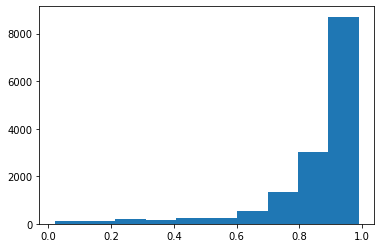

In [7]:
plt.hist(df["grad_rate"])

### Evaluation Metrics

In [47]:
def rmspe(preds, gt):
    """Finds the root mean-square prediction error between a list/series of predictions, preds, and a list/series of ground-truths, gt."""
    if len(preds) != len(gt): return ValueError("predictions and ground-truth vectors must be the same length!")
    preds,gt = preds.tolist(),gt.tolist()
    sse = sum([(gt[i] - preds[i])**2 for i in range(len(gt))])
    return sqrt((1/len(gt))*sse)

def tau(preds, gt, c: float=2.0):
    """Finds the tau size of the prediction error given a list/series of predictions, preds, and a list/series of ground-truths, gt, and a cutoff c."""
    if len(preds) != len(gt): return ValueError("predictions and ground-truth vectors must be the same length!")
    if c <= 0: return ValueError("the cutoff c must be greater than zero!")
    preds,gt = preds.tolist(),gt.tolist()
    median_error = median([abs(gt[i] - preds[i]) for i in range(len(gt))])
    sum_winsorized_error = sum([min(c,abs(gt[i] - preds[i])/median_error)**2 for i in range(len(gt))])
    return sqrt((1/len(gt))*sum_winsorized_error)

In [9]:
#before training our model, we need to numerify our categorical vars! we can do this easily w/ get_dummies: https://stackoverflow.com/questions/58101126/using-scikit-learn-onehotencoder-with-a-pandas-dataframe
categorical_features = ['school_type','magnet','urban_centric_locale','lunch_program']
for cf in categorical_features:
    if cf not in df.columns: continue #in case you're running again
    df = pd.get_dummies(df,prefix=[cf], columns=[cf])
df

,grad_rate,teachers_per_student,support_per_teacher,log_math_pass,log_read_pass,avg_salaries_admin_per_student,avg_teacher_salaries,logit_grad_rate,school_type_Other/alternative,school_type_Regular,school_type_Vocational,magnet_no,magnet_yes,urban_centric_locale_City,urban_centric_locale_Rural,urban_centric_locale_Suburb,urban_centric_locale_Town,lunch_program_no,lunch_program_yes
0,0.94,0.053621,0.300390,3.610918,3.465736,254.245125,49103.324675,2.751535,0,1,0,1,0,0,0,0,1,0,1
1,0.95,0.052045,0.178571,3.737670,3.295837,279.946736,55422.250000,2.944439,0,1,0,1,0,0,1,0,0,1,0
2,0.87,0.050761,0.166667,3.610918,3.737670,275.516629,55165.800000,1.900959,0,1,0,1,0,0,1,0,0,1,0
3,0.97,0.053452,0.208333,4.043051,4.043051,333.421423,52355.166667,3.476099,0,1,0,1,0,0,1,0,0,1,0
4,0.87,0.049521,0.129032,3.737670,3.091042,264.346570,49686.709677,1.900959,0,1,0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14666,0.75,0.147059,0.704667,3.901973,3.901973,3685.318627,48781.400000,1.098612,0,1,0,1,0,0,1,0,0,0,1
14667,0.92,0.072165,0.622449,4.094345,4.143135,493.097202,74499.387755,2.442347,0,1,0,1,0,0,1,0,0,0,1
14668,0.74,0.148936,0.714286,3.401197,2.302585,2370.468085,81567.285714,1.045969,0,1,0,1,0,0,0,0,1,0,1
14669,0.90,0.153846,0.816667,3.795489,3.795489,975.961538,52946.916667,2.197225,0,1,0,1,0,0,1,0,0,0,1


### Model 1: All Predictors

(array([  16.,   87.,  116.,  374.,  486., 1485., 3175., 4096., 4319.,
         517.]),
 array([-3.8918203 , -3.04312628, -2.19443227, -1.34573825, -0.49704424,
         0.35164978,  1.20034379,  2.04903781,  2.89773182,  3.74642584,
         4.59511985]),
 <BarContainer object of 10 artists>)

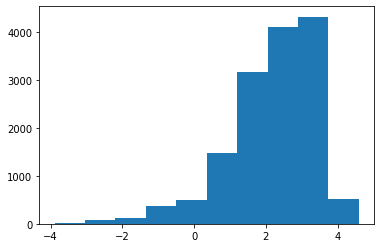

In [10]:
plt.hist(df["logit_grad_rate"])

In [25]:
X = df.drop(["grad_rate","logit_grad_rate"], axis=1)
y = df["logit_grad_rate"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [26]:
m1 = LinearRegression()
m1.fit(X_train, y_train)
preds,gt = m1.predict(X_test).tolist(),y_test.tolist()
print(f"RMPSE: {rmspe(preds,gt)}\tTau: {tau(preds,gt,2)}")

RMPSE: 0.9588975362827781	Tau: 1.2332229465718298


### Model 2: Most Predictors

In [27]:
X = df.drop(["grad_rate","logit_grad_rate","avg_teacher_salaries","magnet_no","magnet_yes","lunch_program_no","lunch_program_yes"], axis=1)
y = df["logit_grad_rate"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [28]:
m2 = LinearRegression()
m2.fit(X_train, y_train)
preds,gt = m2.predict(X_test).tolist(),y_test.tolist()
print(f"RMPSE: {rmspe(preds,gt)}\tTau: {tau(preds,gt,2)}")

RMPSE: 0.9571383604180135	Tau: 1.2338707107371552


### Model 3: Just Reading and Math

In [29]:
X = df[["log_math_pass","log_read_pass"]]
y = df["logit_grad_rate"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [30]:
m3 = LinearRegression()
m3.fit(X_train, y_train)
preds,gt = m3.predict(X_test).tolist(),y_test.tolist()
print(f"RMPSE: {rmspe(preds,gt)}\tTau: {tau(preds,gt,2)}")

RMPSE: 1.0412517624899014	Tau: 1.2622627321732185


## K-Fold Cross Validation

In [33]:
#got help from: https://isheunesu48.medium.com/cross-validation-using-k-fold-with-scikit-learn-cfc44bf1ce6
feature_sets = [
    ['teachers_per_student',
     'support_per_teacher',
     'log_math_pass',
     'log_read_pass',
     'avg_salaries_admin_per_student',
     'avg_teacher_salaries',
     'school_type_Other/alternative',
     'school_type_Regular',
     'school_type_Vocational',
     'magnet_no',
     'magnet_yes',
     'urban_centric_locale_City',
     'urban_centric_locale_Rural',
     'urban_centric_locale_Suburb',
     'urban_centric_locale_Town',
     'lunch_program_no',
     'lunch_program_yes'],
    ['teachers_per_student',
     'support_per_teacher',
     'log_math_pass',
     'log_read_pass',
     'avg_salaries_admin_per_student',
     'school_type_Other/alternative',
     'school_type_Regular',
     'school_type_Vocational',
     'urban_centric_locale_City',
     'urban_centric_locale_Rural',
     'urban_centric_locale_Suburb',
     'urban_centric_locale_Town'],
    ['log_math_pass',
     'log_read_pass']
]

In [36]:
from sklearn.metrics import make_scorer

In [50]:
def all_models_repK(df: pd.DataFrame, feature_sets: list, n_repeats: int, n_splits: int, c: float=2.0):
    """Runs n_repeats repetitions of k-fold cross validations where k=n_splits."""
    #data prep N
    scores = []
    metrics = {
        "rmspe": make_scorer(rmspe),
        "tau": make_scorer(tau)
    }
    for feature_set in feature_sets:
        X,y = df[feature_set],df["logit_grad_rate"]
        model = LinearRegression()
        rkf = RepeatedKFold(n_repeats=n_repeats,n_splits=n_splits)
        score = cross_validate(model, X, y, cv=rkf, scoring=metrics)
        scores.append(score)
    return scores

In [51]:
all_models_repK(df, feature_sets, 50, 10, 3.0)

[{'fit_time': array([0.01748538, 0.01419687, 0.01199651, 0.0089972 , 0.01301885,
         0.01902318, 0.0217638 , 0.01843905, 0.0169704 , 0.00998545,
         0.01200271, 0.01931977, 0.01822495, 0.01971149, 0.01099372,
         0.01000023, 0.00899911, 0.01109004, 0.01802731, 0.01997685,
         0.00921082, 0.01926184, 0.02042961, 0.01554084, 0.01841974,
         0.01982832, 0.01900125, 0.01468754, 0.01377416, 0.01300144,
         0.01901126, 0.02110648, 0.01920676, 0.01814961, 0.01200461,
         0.01053166, 0.01450515, 0.01992846, 0.01230335, 0.0099988 ,
         0.01400065, 0.01800823, 0.00717092, 0.03405762, 0.01209688,
         0.01977611, 0.0167973 , 0.01596212, 0.01397777, 0.01801395,
         0.01969981, 0.01046276, 0.0243535 , 0.01093459, 0.01836705,
         0.01810265, 0.01900029, 0.01700568, 0.01007009, 0.01157236,
         0.01207757, 0.01064658, 0.01099944, 0.01106334, 0.0110805 ,
         0.00904322, 0.01108456, 0.0082047 , 0.01606512, 0.01999784,
         0.01599956, 0

Looks like our non-parallelized version runs well!

## Parallelization

In [ ]:
import multiprocessing
multiprocessing.cpu_count()

In [64]:
def make_groups(num_reps: int, num_jobs: int):
    """Divides num_reps by num_jobs such that no group is more than one larger than another."""
    #Note: I know we discussed this in class but I forget the simpler way of doing this!
    r = num_reps%num_jobs
    groupsize = int(num_reps/num_jobs)
    groups = []
    for i in range(num_jobs):
        if r > 0:
            groups.append(groupsize+1)
            r-=1
        else:
            groups.append(groupsize)
    return groups

def run_jobs(n_jobs: int, df: pd.DataFrame, feature_sets: list, n_repeats: int=50, n_splits: int=10, c: float=2.0):
    """High-level function which parallelizes all_models_repK for n_jobs."""
    #links for joblib
    #https://stackoverflow.com/questions/67237020/how-to-parallelize-multiple-model-building-procedures-in-sklearn
    #https://stackoverflow.com/questions/42220458/what-does-the-delayed-function-do-when-used-with-joblib-in-python
    #TODO: makes reps like [17,17,16] for n_repeats = 50 and jobs = 3
    reps = make_groups(n_repeats, n_jobs)
    results = Parallel(n_jobs=n_jobs)(delayed(all_models_repK)(df, feature_sets, r, n_splits, c) for r in reps)
    return results

In [63]:
#just as expected
make_groups(50,3)

[17, 17, 16]

In [103]:
partition_results = run_jobs(3, df, feature_sets)
#returns list(list(dict)). outer list is number of jobs, inner list of for each model, dict is for each metric.

#aggregate results by model type
model_results = {i:{"rmspe":[],"tau":[]} for i in range(len(partition_results[0]))}
for partition_n,partition_data in enumerate(partition_results):
    for model_n,model_data in enumerate(partition_data): #model_n is 0 indexed
        model_results[model_n]["rmspe"].extend(model_data["test_rmspe"])
        model_results[model_n]["tau"].extend(model_data["test_tau"])
        
#display model results
for i in range(len(model_results)):
    print(f"Model #{i+1} results:\nAverage RMSPE:{mean(model_results[i]['rmspe'])}\tavg tau: {mean(model_results[i]['tau'])}")

Model #1 results:
Average RMSPE:0.9680286647626328	avg tau: 1.228432128334706
Model #2 results:
Average RMSPE:0.9692619708924373	avg tau: 1.2331588610500621
Model #3 results:
Average RMSPE:1.0500217667503198	avg tau: 1.2599965555231545


Looks great! The results are very similar to the single repetition results from before.